In [1]:
# STEP 1 – Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    precision_recall_curve,
    roc_curve,
    auc
)

In [25]:
# STEP 2 – Load the training dataset
df = pd.read_csv("cell2celltrain.csv")

# Quick checks
print(df.shape)
print(df.columns)
df.head()  

(51047, 58)
Index(['CustomerID', 'Churn', 'MonthlyRevenue', 'MonthlyMinutes',
       'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes',
       'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues',
       'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls',
       'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls',
       'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls',
       'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService',
       'UniqueSubs', 'ActiveSubs', 'ServiceArea', 'Handsets', 'HandsetModels',
       'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH',
       'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner',
       'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers',
       'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard',
       'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser',
       'NotNewCellphoneUser', 'ReferralsMadeBySubscriber'

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [23]:
# STEP 3 – Handle missing values

for col in df.columns:
    if df[col].dtype == "object":
        # Categorical: fill with mode
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        # Numeric: fill with median
        df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum().sum())

0


In [26]:
# STEP 4 – Encode categorical columns
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

print(df.dtypes.head())

CustomerID                int64
Churn                     int64
MonthlyRevenue          float64
MonthlyMinutes          float64
TotalRecurringCharge    float64
dtype: object


In [28]:
# STEP 5 – Define features (X) and target (y) and split

# Target column
target_col = "Churn"

# Columns to drop
drop_cols = [
    "CustomerID",
    "ServiceArea",
    "Occupation",
    "PrizmCode",
    "NewCellphoneUser"
]

# Features and target
X = df.drop(columns=[target_col] + [c for c in drop_cols if c in df.columns])
y = df[target_col]

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)

(40837, 52) (10210, 52)


In [29]:
# Initialize models
dt = DecisionTreeClassifier(random_state=42)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [34]:
# STEP 7 – Evaluation: numeric metrics

def evaluate_model(name, model, X_val, y_val):
    y_pred = model.predict(X_val)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_proba = None

    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_val, y_pred), 4))
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    print("Classification Report:\n", classification_report(y_val, y_pred))

    if y_proba is not None:
        print("ROC AUC:", round(roc_auc_score(y_val, y_proba), 4))
        print("Log Loss:", round(log_loss(y_val, y_proba), 4))

    return y_pred, y_proba

dt_pred, dt_proba = evaluate_model("Decision Tree", dt, X_val, y_val)
rf_pred, rf_proba = evaluate_model("Random Forest", rf, X_val, y_val)



=== Decision Tree ===
Accuracy: 0.6165
Confusion Matrix:
 [[5221 2047]
 [1869 1073]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.72      0.73      7268
           1       0.34      0.36      0.35      2942

    accuracy                           0.62     10210
   macro avg       0.54      0.54      0.54     10210
weighted avg       0.62      0.62      0.62     10210

ROC AUC: 0.5415
Log Loss: 13.8244

=== Random Forest ===
Accuracy: 0.7202
Confusion Matrix:
 [[7094  174]
 [2683  259]]
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.98      0.83      7268
           1       0.60      0.09      0.15      2942

    accuracy                           0.72     10210
   macro avg       0.66      0.53      0.49     10210
weighted avg       0.69      0.72      0.64     10210

ROC AUC: 0.6616
Log Loss: 0.5662


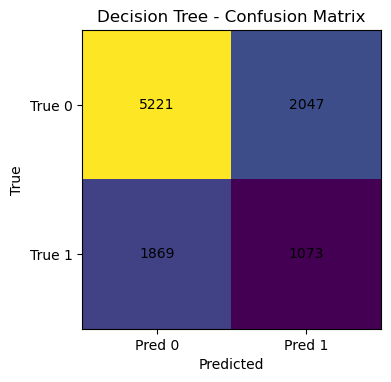

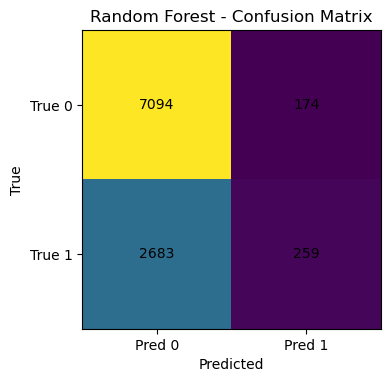

In [31]:
# STEP 8 – Visual 1: Confusion matrices

def plot_confusion(cm, title):
    fig = plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["True 0", "True 1"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

dt_cm = confusion_matrix(y_val, dt_pred)
rf_cm = confusion_matrix(y_val, rf_pred)

plot_confusion(dt_cm, "Decision Tree - Confusion Matrix")
plot_confusion(rf_cm, "Random Forest - Confusion Matrix")

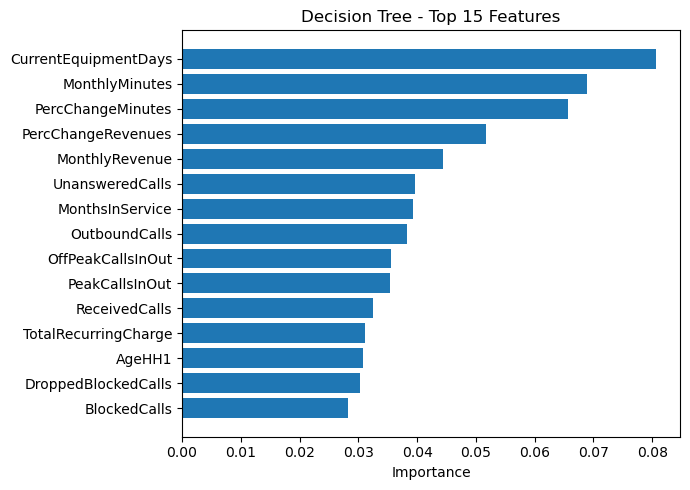

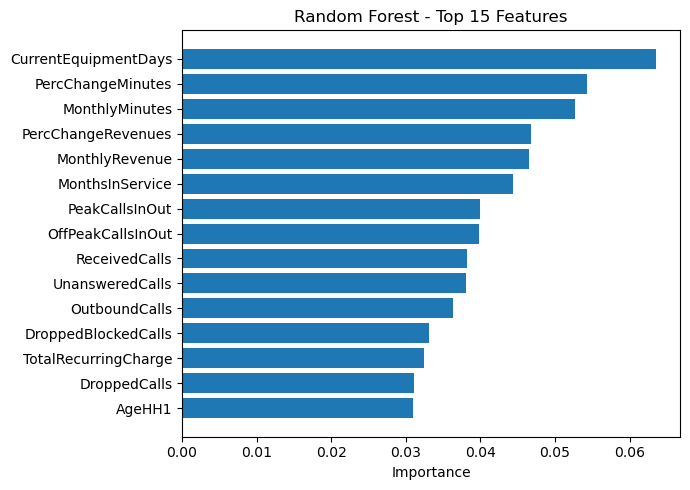

In [32]:
# STEP 9 – Visual 2: Feature importance

def plot_feature_importance(model, feature_names, title, top_k=15):
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:top_k]
    feats = np.array(feature_names)[idx]
    vals = importances[idx]

    fig = plt.figure(figsize=(7, 5))
    y_pos = np.arange(len(feats))
    plt.barh(y_pos, vals)
    plt.yticks(y_pos, feats)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

plot_feature_importance(dt, X.columns, "Decision Tree - Top 15 Features")
plot_feature_importance(rf, X.columns, "Random Forest - Top 15 Features")

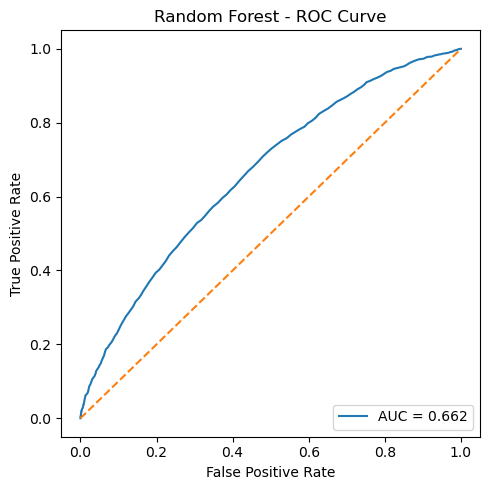

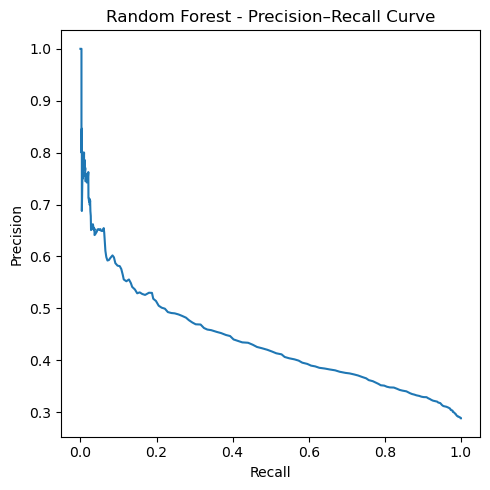

In [35]:
# STEP 10 – ROC & Precision–Recall curves (Random Forest)

# ROC Curve for Random Forest
fpr, tpr, _ = roc_curve(y_val, rf_proba)
roc_auc = auc(fpr, tpr)

fig = plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Precision–Recall Curve for Random Forest
prec, rec, _ = precision_recall_curve(y_val, rf_proba)

fig = plt.figure(figsize=(5, 5))
plt.plot(rec, prec)
plt.title("Random Forest - Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()